# Experimental Validation of PI-ARM for solving Diffusion equation

The 2D diffusion equation is:
$$\frac{\partial u}{\partial t}-\frac{\partial^{2}u}{\partial x^{2}}=f(t,x),$$
where $f(t,x)$ is the source term which was chosen equal to
$$f(t,x)=(\pi^{2}-1)\exp(-t)\sin(\pi x).$$
Additionally, $\Omega=[0,1]\times[0,1]$ is the chosen domain, with the following boundary conditions:
$$u(t = 0,x) = \sin(\pi x),$$
$$u(t,x = 0) = u(t,x = 1) = 0.$$
The exact solution of this PDE is
$$u(t,x) = \sin(\pi x)\exp(-t).$$

In [2]:
import torch
from rkan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = RMultKAN(width=[2,5,1], grid=5, k=5, seed=2, device=device).speed()
# Load model
model = model.loadckpt('./model/Dif_arkan')
model.eval()

# exact solution
sol_fun = lambda x: torch.sin(torch.pi * x[:, [1]]) * torch.exp(-x[:,[0]])

with torch.no_grad():
    x_vals = torch.linspace(0, 1, 100)
    y_vals = torch.linspace(0, 1, 100)
    x_grid, y_grid = torch.meshgrid(x_vals.squeeze(), y_vals.squeeze())
    z_grid = torch.cat([x_grid.reshape(-1, 1), y_grid.reshape(-1, 1)], dim=1).float().to(device)
    
    # Predicted solution and Exact solution
    pred_f = model(z_grid).detach().cpu()
    pred_f = pred_f.reshape(x_vals.shape[0], y_vals.shape[0])
    
    exact_f = sol_fun(z_grid).detach().cpu()
    exact_f = exact_f.reshape(x_vals.shape[0], y_vals.shape[0])
    
# Compute Rel-L2 error
r_l2 = torch.norm(exact_f - pred_f, p=2) / torch.norm(exact_f, p=2)
print(f"Relative L2 error: {r_l2*100: .4f}%")

cuda
checkpoint directory created: ./model
saving model version 0.0


/home/apulis-dev/userdata/ML+PDE/KANs/ARMultKAN/rkan/RMultKAN.py:501: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/home/apulis-dev/user

Relative L2 error:  0.0034%


/tmp/ipykernel_3416806/476478153.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  abs_error = np.abs(pred_f - exact_f)


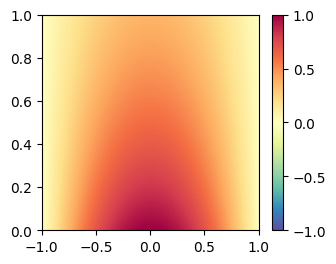

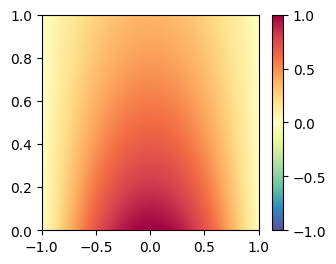

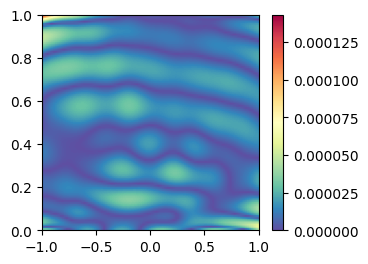

In [3]:
# ---------Visualize the results ---------
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# Define the save path
figure_save_path = r'./figures'

if not os.path.exists(figure_save_path):
    os.makedirs(figure_save_path)

# Fig 1: Heatmap of Predicted Solution
fig1, ax1 = plt.subplots(figsize=(3.5, 2.8))
heatmap1 = ax1.imshow(pred_f, extent=(-1.0, 1.0, y_grid.min(), y_grid.max()), origin='lower', cmap='Spectral_r', aspect='auto',vmin=-1,vmax=1)
#ax1.set_xlabel('t')
#ax1.set_ylabel('x')
#ax1.set_title('Predicted u(t,x) Heatmap', fontsize=15)
cbar1 = fig1.colorbar(heatmap1, ax=ax1, orientation='vertical')
fig1.savefig(os.path.join(figure_save_path, 'Dif_arkan.pdf'), format='pdf', bbox_inches='tight')

# Fig 2: Heatmap of Reference Solution
fig2, ax2 = plt.subplots(figsize=(3.5, 2.8))
heatmap2 = ax2.imshow(exact_f, extent=(-1.0,1.0, y_grid.min(), y_grid.max()), origin='lower', cmap='Spectral_r', aspect='auto',vmin=-1,vmax=1)
#ax2.set_xlabel('t')
#ax2.set_ylabel('x')
#ax2.set_title('Theoretical u(t,x) Heatmap', fontsize=15)
cbar2 = fig2.colorbar(heatmap2, ax=ax2, orientation='vertical')
#fig2.savefig(os.path.join(figure_save_path, 'Dif_exact.pdf'), format='pdf', bbox_inches='tight')

# Fig 3: Heatmap of Absolute Error
abs_error = np.abs(pred_f - exact_f)

fig = plt.figure(figsize=(3.5, 2.8))
plt.imshow(abs_error, extent=[-1.0,1, y_grid.min(), y_grid.max()], origin='lower', aspect='auto', 
           cmap='Spectral_r')
#plt.xlabel('t')
#plt.ylabel('x')
cbar = plt.colorbar()
#cbar.set_label('error')
#fig.savefig(os.path.join(figure_save_path, 'Dif_arkan_error.pdf'), format='pdf', bbox_inches='tight')

plt.show()